In [1]:
''' we will compare 2 models
- time series only
- time series + extracted features from time series''' 

' we will compare 2 models\n- time series only\n- time series + extracted features from time series'

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
import tensorflow as tf
from tensorflow.keras.layers import Dense, Input, GlobalMaxPooling1D, LSTM, Concatenate
from tensorflow.keras.models import Model
from tensorflow.keras.losses import SparseCategoricalCrossentropy # allows us to write from_logits=true, other wise we cant if we just pass the string inside compile
from tensorflow.keras.callbacks import ModelCheckpoint

In [5]:
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler

In [6]:
np.random.seed(0)
tf.random.set_seed(0)

In [7]:
df = pd.read_csv(
    r'G:\My Drive\Study\Time Series Analysis Udemy\Data\time series analysis forecasting\UCI-HAR\UCI HAR Dataset\train\Inertial Signals\body_acc_x_train.txt',
    header = None,
    delim_whitespace = True
)

C:\Users\VARUN\AppData\Local\Temp\ipykernel_12088\3254770097.py:1: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(


In [8]:
df.head()

,0,1,2,3,4,5,6,7,8,9,...,118,119,120,121,122,123,124,125,126,127
0,0.000181,0.010139,0.009276,0.005066,0.010810,0.004045,0.004757,0.006214,0.003307,0.007572,...,0.001412,-0.001509,0.000060,0.000435,-0.000819,0.000228,-0.000300,-0.001147,-0.000222,0.001576
1,0.001094,0.004550,0.002879,0.002247,0.003305,0.002416,0.001619,0.000981,0.000009,-0.000363,...,-0.000104,-0.000141,0.001333,0.001541,0.001077,-0.000736,-0.003767,-0.004646,-0.002941,-0.001599
2,0.003531,0.002285,-0.000420,-0.003738,-0.006706,-0.003148,0.000733,0.000668,0.002162,-0.000946,...,0.000661,0.001853,-0.000268,-0.000394,-0.000279,-0.000316,0.000144,0.001246,0.003117,0.002178
3,-0.001772,-0.001311,0.000388,0.000408,-0.000355,0.000998,0.001109,-0.003149,-0.008882,-0.010483,...,0.000458,0.002103,0.001358,0.000820,-0.000212,-0.001915,-0.001631,-0.000867,-0.001172,-0.000028
4,0.000087,-0.000272,0.001022,0.003126,0.002284,0.000885,0.001933,0.002270,0.002247,0.002175,...,0.002529,0.003518,-0.000248,-0.002761,0.000252,0.003752,0.001626,-0.000698,-0.001223,-0.003328


In [9]:
df.shape

(7352, 128)

In [10]:
''' we have N = 7352 samples and each time series has 128 measurements as explained in notes
50 recordings per second and each recording being 2.56 secs long ~2.56*50 = 128 measurements in each time series of 2.56 secs  
'''

' we have N = 7352 samples and each time series has 128 measurements as explained in notes\n50 recordings per second and each recording being 2.56 secs long ~2.56*50 = 128 measurements in each time series of 2.56 secs  \n'

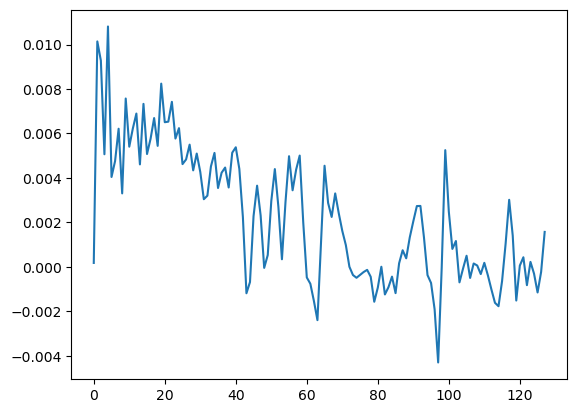

In [11]:
# plotting just 1st row or say one recording out of 7352 recordings of 2.56 seconds containing 128 measurements
df.iloc[0].plot();

# time series model using time series only

In [12]:
T = 128
Ntrain = 7352 
Ntest = 2947  # look at any data file inside G:\My Drive\Study\Time Series Analysis Udemy\Data\time series analysis forecasting\UCI-HAR\UCI HAR Dataset\test\Inertial Signals
D = 9 # 9 time series
K = 6 # num of classes

In [13]:
def load_data():
    # returns:
    # Xtrain (Ntrain * T * D), Ytrain (Ntrain)
    # Xtest (Ntest * T * D), Ytest (Ntest)
    
    Xtrain = np.zeros((Ntrain, T, D))
    Xtest = np.zeros((Ntest, T, D))

    #train data
    ts_filenames = [
        'body_acc_x_train.txt', 'body_gyro_x_train.txt', 'total_acc_x_train.txt',
        'body_acc_y_train.txt', 'body_gyro_y_train.txt', 'total_acc_y_train.txt',
        'body_acc_z_train.txt', 'body_gyro_z_train.txt', 'total_acc_z_train.txt',
    ]

    ts_file_prefix = 'G:/My Drive/Study/Time Series Analysis Udemy/Data/time series analysis forecasting/UCI-HAR/UCI HAR Dataset/train/'

    for d, fn in enumerate(ts_filenames):
        df = pd.read_csv(
            f'{ts_file_prefix}Inertial Signals/{fn}',
            header = None,
            delim_whitespace = True)
        
        # Ntrain * T array
        x = df.to_numpy()
        Xtrain[:,:,d] = x

    Ytrain = pd.read_csv(f'{ts_file_prefix}/y_train.txt', header = None).to_numpy() - 1 # doing minus 1 since we want it to start from 0 instead of 1
    Ytrain = Ytrain.flatten()

    #test data
    ts_filenames = [
        'body_acc_x_test.txt', 'body_gyro_x_test.txt', 'total_acc_x_test.txt',
        'body_acc_y_test.txt', 'body_gyro_y_test.txt', 'total_acc_y_test.txt',
        'body_acc_z_test.txt', 'body_gyro_z_test.txt', 'total_acc_z_test.txt',
    ]

    ts_file_prefix = 'G:/My Drive/Study/Time Series Analysis Udemy/Data/time series analysis forecasting/UCI-HAR/UCI HAR Dataset/test/'

    for d, fn in enumerate(ts_filenames):
        df = pd.read_csv(
            f'{ts_file_prefix}Inertial Signals/{fn}',
            header = None,
            delim_whitespace = True)
        
        # Ntrain * T array
        x = df.to_numpy()
        Xtest[:,:,d] = x

    Ytest = pd.read_csv(f'{ts_file_prefix}/y_test.txt', header = None).to_numpy() - 1 # doing minus 1 since we want it to start from 0 instead of 1
    Ytest = Ytest.flatten()

    return Xtrain, Ytrain, Xtest, Ytest    
        

In [14]:
Xtrain, Ytrain, Xtest, Ytest = load_data()

C:\Users\VARUN\AppData\Local\Temp\ipykernel_12088\1734865465.py:19: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(
C:\Users\VARUN\AppData\Local\Temp\ipykernel_12088\1734865465.py:19: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(
C:\Users\VARUN\AppData\Local\Temp\ipykernel_12088\1734865465.py:19: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(
C:\Users\VARUN\AppData\Local\Temp\ipykernel_12088\1734865465.py:19: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(
C:\Users\VARUN\AppData\Local\Temp\ipykernel_12088\1734865465.py:19: FutureWarnin

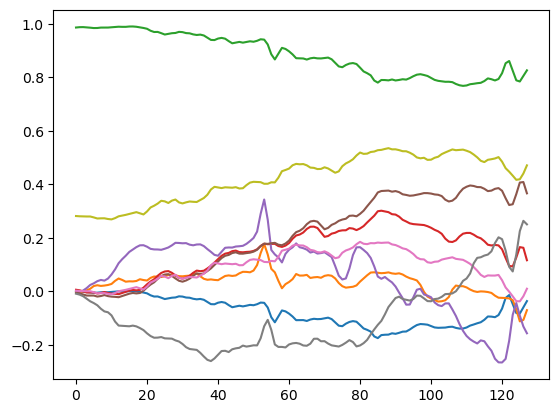

In [15]:
# plot all D time series of length T = 128 for one sample say 7000

# plt.figure(figsize =(15,5))
plt.plot(Xtrain[7000,:,:]);
# plt.show();

In [18]:
# RNN
i = Input(shape=(T,D)) # D is like the embedding vector /vocabulary dictionary for NLP for a word x(1)
x = LSTM(32, return_sequences=True)(i) 
# x = LSTM(32, retrun_sequences=True)(x) 
x = GlobalMaxPooling1D()(x)
x = Dense(K)(x)
model = Model(i,x)

In [19]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 128, 9)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 128, 32)        │         5,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_1          │ (None, 32)             │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           198 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,574 (21.77 KB)

 Trainable params: 5,574 (21.77 KB)

 Non-trainable params: 0 (0.00 B)

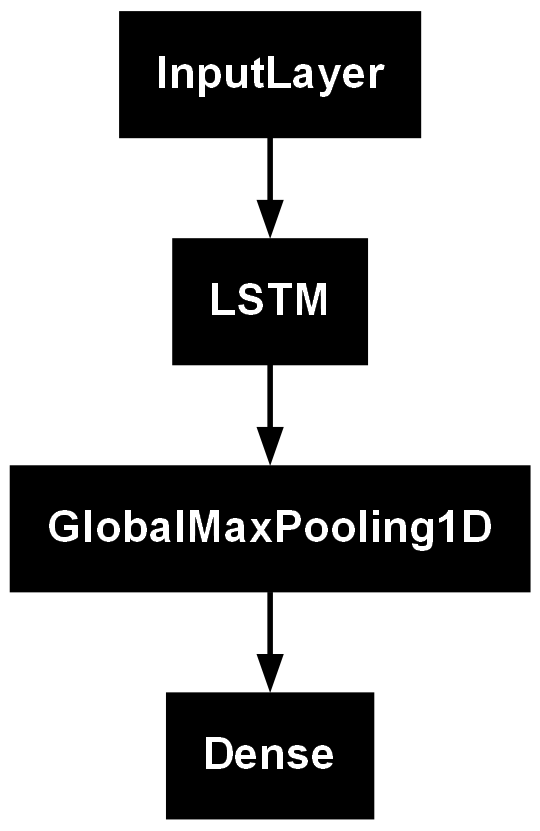

In [20]:
tf.keras.utils.plot_model(model)

In [21]:
checkpoint = ModelCheckpoint('best_model.h5', monitor ='val_accuracy', save_best_only = True)

In [22]:
model.compile(
    loss = SparseCategoricalCrossentropy(from_logits =True), 
    optimizer = 'adam',
    metrics = ['accuracy'],
)

In [23]:
r = model.fit(
    Xtrain, # note here that the Xtrain size is N x T x D, in ANN code, we had 9 different splitted X_trains each of dimension N x T
    Ytrain,
    epochs = 10,
    callbacks = [checkpoint],
    validation_data = (Xtest, Ytest))

Epoch 1/10
230/230 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.5600 - loss: 1.3563

230/230 ━━━━━━━━━━━━━━━━━━━━ 12s 41ms/step - accuracy: 0.7091 - loss: 1.0515 - val_accuracy: 0.8140 - val_loss: 0.7262
Epoch 2/10
229/230 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.8784 - loss: 0.5575

230/230 ━━━━━━━━━━━━━━━━━━━━ 10s 45ms/step - accuracy: 0.8976 - loss: 0.4642 - val_accuracy: 0.8683 - val_loss: 0.4534
Epoch 3/10
230/230 ━━━━━━━━━━━━━━━━━━━━ 10s 45ms/step - accuracy: 0.9272 - loss: 0.2868 - val_accuracy: 0.8633 - val_loss: 0.4324
Epoch 4/10
230/230 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.9322 - loss: 0.2311

230/230 ━━━━━━━━━━━━━━━━━━━━ 9s 39ms/step - accuracy: 0.9369 - loss: 0.2131 - val_accuracy: 0.8741 - val_loss: 0.3615
Epoch 5/10
230/230 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.9361 - loss: 0.1978

230/230 ━━━━━━━━━━━━━━━━━━━━ 9s 40ms/step - accuracy: 0.9387 - loss: 0.1994 - val_accuracy: 0.8833 - val_loss: 0.3275
Epoch 6/10
230/230 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.9425 - loss: 0.1752

230/230 ━━━━━━━━━━━━━━━━━━━━ 10s 44ms/step - accuracy: 0.9429 - loss: 0.1724 - val_accuracy: 0.8901 - val_loss: 0.2829
Epoch 7/10
230/230 ━━━━━━━━━━━━━━━━━━━━ 10s 43ms/step - accuracy: 0.9410 - loss: 0.1723 - val_accuracy: 0.8782 - val_loss: 0.3429
Epoch 8/10
230/230 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.9394 - loss: 0.1697

230/230 ━━━━━━━━━━━━━━━━━━━━ 9s 40ms/step - accuracy: 0.9472 - loss: 0.1517 - val_accuracy: 0.8938 - val_loss: 0.2858
Epoch 9/10
230/230 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.9451 - loss: 0.1441

230/230 ━━━━━━━━━━━━━━━━━━━━ 9s 38ms/step - accuracy: 0.9482 - loss: 0.1366 - val_accuracy: 0.9023 - val_loss: 0.2688
Epoch 10/10
229/230 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.9454 - loss: 0.1333

230/230 ━━━━━━━━━━━━━━━━━━━━ 11s 48ms/step - accuracy: 0.9479 - loss: 0.1316 - val_accuracy: 0.9091 - val_loss: 0.2665


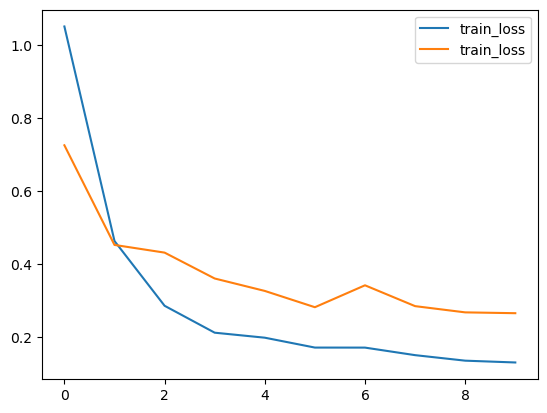

In [24]:
plt.plot(r.history['loss'], label = 'train_loss')
plt.plot(r.history['val_loss'], label = 'train_loss')
plt.legend();

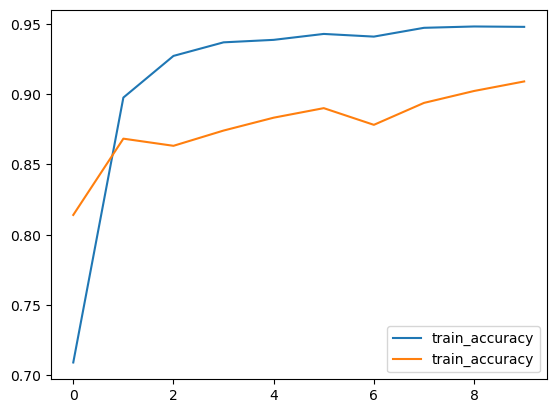

In [25]:
plt.plot(r.history['accuracy'], label = 'train_accuracy')
plt.plot(r.history['val_accuracy'], label = 'train_accuracy')
plt.legend();

In [26]:
''' accuracy seems quite low compared to the other models we have seen'''

' accuracy seems quite low compared to the other models we have seen'

In [27]:
# load best model
best_model = tf.keras.models.load_model('best_model.h5')

In [28]:
# make predictions
ptest = best_model.predict(Xtest)

93/93 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step  


In [29]:
print(ptest.shape)
print(ptest[0].shape)

(2947, 6)
(6,)


In [30]:
#evaluate
np.mean(np.argmax(ptest, axis = 1)==Ytest)

np.float64(0.9090600610790635)

In [31]:
''' underperforms compared to the other models we have studied'''

' underperforms compared to the other models we have studied'

# comparing this with a combined model containing inputs from the raw time series as well as the precomputed features from the same time series as an input

In [32]:
''' note that we are going to use a file containing pre extracted features which we are not going to compute. this is already done using
the original time series showed in the above section'''

' note that we are going to use a file containing pre extracted features which we are not going to compute. this is already done using\nthe original time series showed in the above section'

In [33]:
from sklearn.preprocessing import StandardScaler

def load_features():
    # returns 
    # X_train (Ntrain X D)
    # X_test (Ntest X D)

    # train data
    df = pd.read_csv(
        r'G:\My Drive\Study\Time Series Analysis Udemy\Data\time series analysis forecasting\UCI-HAR\UCI HAR Dataset\train\X_train.txt',
        header = None,
        delim_whitespace = True)
    # these features are already precomputed from the original time series explained in the section above

    feat_train = df.to_numpy()

    #test data
    df = pd.read_csv(
        r'G:\My Drive\Study\Time Series Analysis Udemy\Data\time series analysis forecasting\UCI-HAR\UCI HAR Dataset\test\X_test.txt',
        header = None,
        delim_whitespace = True)

    feat_test = df.to_numpy()

    scaler = StandardScaler()
    feat_train = scaler.fit_transform(feat_train)
    feat_test = scaler.transform(feat_test)

    return feat_train, feat_test  



In [34]:
feat_train, feat_test = load_features()

C:\Users\VARUN\AppData\Local\Temp\ipykernel_12088\1250225645.py:9: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(
C:\Users\VARUN\AppData\Local\Temp\ipykernel_12088\1250225645.py:18: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(


In [35]:
feat_train.shape

(7352, 561)

In [36]:
D_feat = feat_train.shape[1]
D_feat #this is the number of columns in the features

561

In [37]:
# combined model using time series and already extracted features 

#RNN
i = Input(shape=(T,D)) # D is like the embedding vector /vocabulary dictionary for NLP for a word x(1)
x = LSTM(32, return_sequences= True)(i) 
x = GlobalMaxPooling1D()(x)

#ANN
i2 = Input(shape=(D_feat,))
x2 = Dense(32, activation ='relu')(i2)

x = Concatenate()([x, x2])
x = Dense(K)(x)

model = Model([i, i2],x)

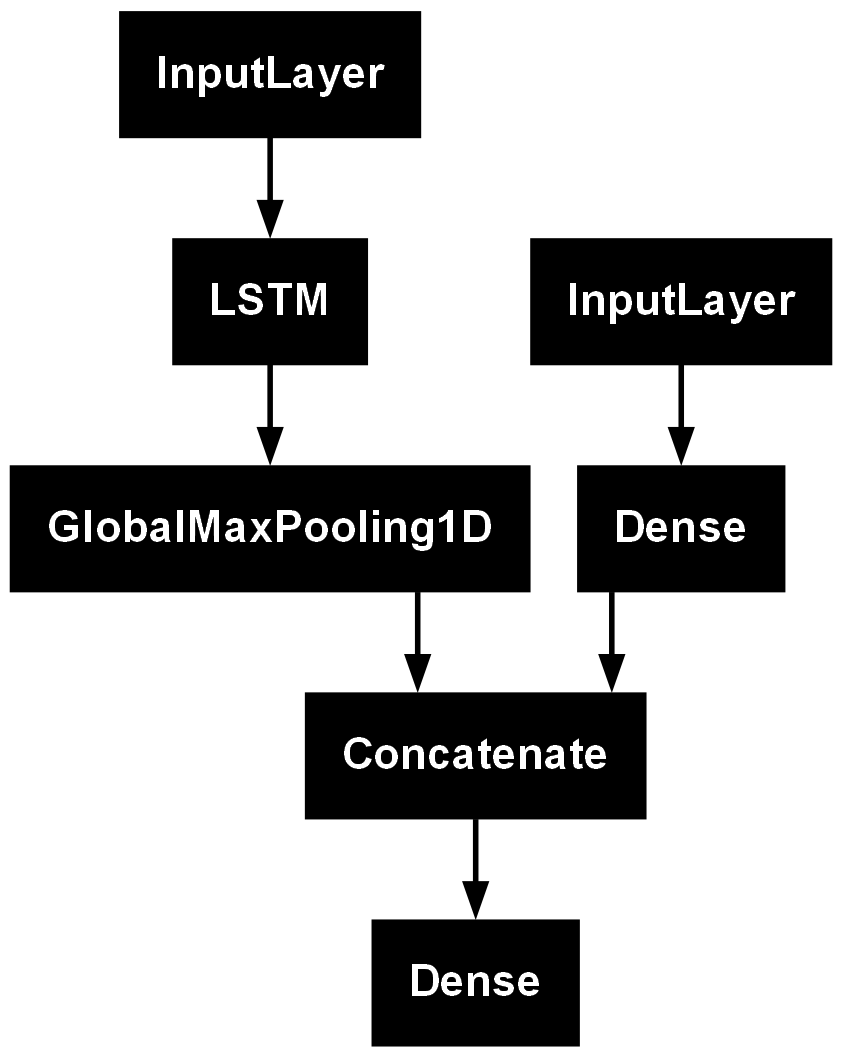

In [38]:
tf.keras.utils.plot_model(model)

In [39]:
check_point3 = ModelCheckpoint('best_model_combined.h5', monitor = 'val_accuracy', save_best_only=True)

In [40]:
model.compile(
    loss = SparseCategoricalCrossentropy(from_logits = True),
    optimizer = 'adam',
    metrics =['accuracy'],)
    

In [41]:
r = model.fit(
    [Xtrain, feat_train],
    Ytrain,
    epochs = 15,
    callbacks = [check_point3],
    validation_data = ([Xtest, feat_test], Ytest),)

Epoch 1/15
229/230 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.7063 - loss: 0.7708

230/230 ━━━━━━━━━━━━━━━━━━━━ 14s 49ms/step - accuracy: 0.8587 - loss: 0.3944 - val_accuracy: 0.9352 - val_loss: 0.1959
Epoch 2/15
229/230 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.9558 - loss: 0.1252

230/230 ━━━━━━━━━━━━━━━━━━━━ 11s 46ms/step - accuracy: 0.9642 - loss: 0.1090 - val_accuracy: 0.9416 - val_loss: 0.1603
Epoch 3/15
229/230 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.9676 - loss: 0.0845 

230/230 ━━━━━━━━━━━━━━━━━━━━ 20s 44ms/step - accuracy: 0.9742 - loss: 0.0746 - val_accuracy: 0.9430 - val_loss: 0.1564
Epoch 4/15
230/230 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.9787 - loss: 0.0608

230/230 ━━━━━━━━━━━━━━━━━━━━ 10s 43ms/step - accuracy: 0.9814 - loss: 0.0570 - val_accuracy: 0.9440 - val_loss: 0.1599
Epoch 5/15
229/230 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.9816 - loss: 0.0515

...

230/230 ━━━━━━━━━━━━━━━━━━━━ 11s 47ms/step - accuracy: 0.9859 - loss: 0.0441 - val_accuracy: 0.9450 - val_loss: 0.1591
Epoch 7/15
230/230 ━━━━━━━━━━━━━━━━━━━━ 11s 46ms/step - accuracy: 0.9871 - loss: 0.0397 - val_accuracy: 0.9444 - val_loss: 0.1676
Epoch 8/15
229/230 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.9892 - loss: 0.0380

230/230 ━━━━━━━━━━━━━━━━━━━━ 19s 41ms/step - accuracy: 0.9902 - loss: 0.0356 - val_accuracy: 0.9454 - val_loss: 0.1661
Epoch 9/15
230/230 ━━━━━━━━━━━━━━━━━━━━ 9s 41ms/step - accuracy: 0.9903 - loss: 0.0320 - val_accuracy: 0.9454 - val_loss: 0.1717
Epoch 10/15
230/230 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.9888 - loss: 0.0322

230/230 ━━━━━━━━━━━━━━━━━━━━ 10s 41ms/step - accuracy: 0.9905 - loss: 0.0293 - val_accuracy: 0.9477 - val_loss: 0.1650
Epoch 11/15
229/230 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.9915 - loss: 0.0284

230/230 ━━━━━━━━━━━━━━━━━━━━ 10s 45ms/step - accuracy: 0.9925 - loss: 0.0265 - val_accuracy: 0.9484 - val_loss: 0.1685
Epoch 12/15
229/230 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.9913 - loss: 0.0269

230/230 ━━━━━━━━━━━━━━━━━━━━ 9s 41ms/step - accuracy: 0.9924 - loss: 0.0247 - val_accuracy: 0.9491 - val_loss: 0.1697
Epoch 13/15
230/230 ━━━━━━━━━━━━━━━━━━━━ 10s 40ms/step - accuracy: 0.9929 - loss: 0.0226 - val_accuracy: 0.9477 - val_loss: 0.1755
Epoch 14/15
230/230 ━━━━━━━━━━━━━━━━━━━━ 9s 38ms/step - accuracy: 0.9931 - loss: 0.0208 - val_accuracy: 0.9481 - val_loss: 0.1737
Epoch 15/15
230/230 ━━━━━━━━━━━━━━━━━━━━ 8s 37ms/step - accuracy: 0.9928 - loss: 0.0202 - val_accuracy: 0.9471 - val_loss: 0.1842


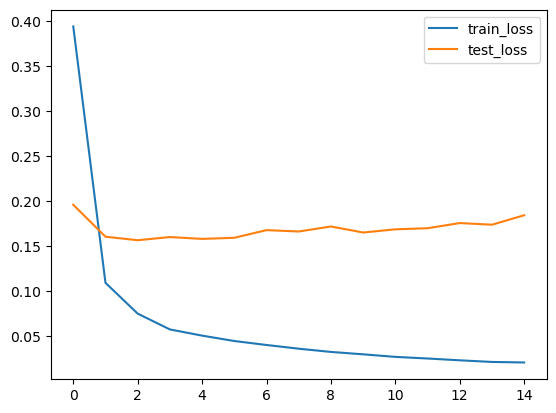

In [42]:
plt.plot(r.history['loss'], label = 'train_loss')
plt.plot(r.history['val_loss'], label = 'test_loss')
plt.legend();

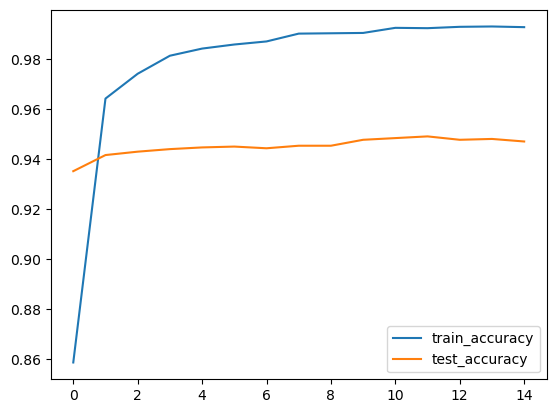

In [43]:
plt.plot(r.history['accuracy'], label = 'train_accuracy')
plt.plot(r.history['val_accuracy'], label = 'test_accuracy')
plt.legend();

In [45]:
''' looks better but still not outperforming the previous models using CNN before'''

' looks better but still not outperforming the previous models using CNN before'

In [46]:
#load best model
best_model = tf.keras.models.load_model('best_model_combined.h5')

In [47]:
#make predictions
ptest = best_model.predict([Xtest, feat_test])

93/93 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step


In [48]:
#evaluate
np.mean(np.argmax(ptest, axis=1)==Ytest)

np.float64(0.9491007804546997)

In [54]:
''' this is much better than the time series model.

also looking at the combined model (done in a separate notebook) built using ANNs only and not using CNN, this model using CNN performs 
slightly better

However, the best model was logistic regression model done in the previous notebook which used just the features extracted from the time series
'''


' this is much better than the time series model.\n\nalso looking at the combined model (done in a separate notebook) built using ANNs only and not using CNN, this model using CNN performs \nslightly better\n\nHowever, the best model was logistic regression model done in the previous notebook which used just the features extracted from the time series\n'